# Beam Strength: Theory vs Actual Failure

For each beam in the 2-variable dataset, compute predicted bending and LTB failure loads, compare to measured ultimate failure, and investigate whether the ratio `k = P_actual / P_ltb` is constant or depends on beam geometry.

Material: Sunlu PLA+ 2.0 (blue), datasheet values (ASTM D790).  
J uses Timoshenko finite-thickness correction throughout.  
No fillets in these designs.

**Web shear:** For very thin webs, a useful limit load is web shear yielding: V_n ~ tau_y * b * H with tau_y = sigma_y/sqrt(3) (von Mises), and P = 2*V_n for 3-point bending. Structural steel codes use V_n = 0.6*Fy*Aw (nearly the same tau_y). This is not calibrated for FDM: layer bonds and stress concentrations can govern.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Material: Sunlu PLA+ 2.0 (ASTM D790 / D638 datasheet) ---
E = 2.74e9           # Pa, flexural modulus
SIGMA_Y = 81.8e6     # Pa, flexural strength
G = E / 2.6          # Pa, shear modulus (nu ~ 0.3)

# --- Geometry constants ---
TOTAL_H = 25.0       # mm, total beam height
B = 16.0             # mm, flange width
L = 0.2023           # m, span (3-point bending)
C1 = 1.35            # moment gradient factor for 3-point bending
Y_MAX = TOTAL_H / 2e3  # m, neutral axis to extreme fiber

In [2]:
# === Section property functions ===
# All inputs in mm, all outputs in m^4 (or m for distances)

def calc_Ix(H_mm, b_mm, B_mm=B, total_h=TOTAL_H):
    """Strong-axis second moment of area (m^4)."""
    H, b, Bf = H_mm/1e3, b_mm/1e3, B_mm/1e3
    h = (total_h/1e3 - H) / 2.0
    if h <= 0: return 0.0
    return (b * H**3)/12 + 2*(Bf * h**3/12 + Bf * h * ((H + h)/2)**2)

def calc_Iy(H_mm, b_mm, B_mm=B, total_h=TOTAL_H):
    """Weak-axis second moment of area (m^4)."""
    H, b, Bf = H_mm/1e3, b_mm/1e3, B_mm/1e3
    h = (total_h/1e3 - H) / 2.0
    if h <= 0: return 0.0
    return (H * b**3)/12 + 2*(h * Bf**3)/12

def _beta(t, a):
    """Timoshenko correction for rectangular torsion constant.
    t = short dim, a = long dim.  J_rect = beta * a * t^3.
    Thin-wall limit (t/a -> 0): beta -> 1/3."""
    if a <= 0 or t <= 0: return 1.0/3.0
    r = min(t, a) / max(t, a)
    return (1.0/3.0) * (1.0 - 0.63*r + 0.052*r**5)

def calc_J(H_mm, b_mm, B_mm=B, total_h=TOTAL_H):
    """Torsional constant with Timoshenko correction (m^4)."""
    H, b, Bf = H_mm/1e3, b_mm/1e3, B_mm/1e3
    h = (total_h/1e3 - H) / 2.0
    if h <= 0: return 0.0
    J_web = _beta(min(b, H), max(b, H)) * max(b, H) * min(b, H)**3
    J_fl  = _beta(min(h, Bf), max(h, Bf)) * max(h, Bf) * min(h, Bf)**3
    return J_web + 2 * J_fl

In [3]:
# === Strength predictions ===

def beam_calcs(H_mm, b_mm):
    Ix = calc_Ix(H_mm, b_mm)
    Iy = calc_Iy(H_mm, b_mm)
    J  = calc_J(H_mm, b_mm)

    My = SIGMA_Y * Ix / Y_MAX
    Mcr = (C1 * np.pi / L) * np.sqrt(E * Iy * G * J) if (Iy > 0 and J > 0) else 0.0
    R = Mcr / My if My > 0 else 0.0

    P_bend = 4 * My / L
    P_ltb  = 4 * Mcr / L
    P_gov  = min(P_bend, P_ltb)

    # Web shear yield (3-point bend, V_max = P/2): V carried by web area Aw = b*H.
    # tau_y = sigma_y/sqrt(3) (von Mises); structural steel often uses 0.6*Fy (similar).
    # Domain: no shear buckling (check tau_cr >> tau_y), no web crippling under load point,
    # shear strength ~ flexural sigma_y (not true for weak interlayers in FDM).
    H_m, b_m = H_mm / 1e3, b_mm / 1e3
    A_web = b_m * H_m
    tau_y = SIGMA_Y / np.sqrt(3)
    P_shear = 2.0 * tau_y * A_web  # V_n = tau_y * Aw, P = 2*V_n at max shear (center-loaded span)
    P_triple = min(P_bend, P_ltb, P_shear)

    return {
        'Ix_mm4': Ix * 1e12,   # convert m^4 -> mm^4 for readability
        'Iy_mm4': Iy * 1e12,
        'J_mm4':  J  * 1e12,
        'My_Nm':  My,
        'Mcr_Nm': Mcr,
        'R': R,
        'P_bend': P_bend,
        'P_ltb':  P_ltb,
        'P_gov':  P_gov,
        'P_shear': P_shear,
        'P_triple': P_triple,
    }

In [4]:
# === Load data and compute everything ===
DATA_URL = (
    "https://raw.githubusercontent.com/andrewvoss8-boop/"
    "core-me-data-science-activities-public/main/data/I_beam_data_2var.csv"
)

def load_data():
    import urllib.request, io
    print("Downloading data...")
    with urllib.request.urlopen(DATA_URL) as r:
        return pd.read_csv(io.StringIO(r.read().decode("utf-8")))

df = load_data()

rows = []
for _, r in df.iterrows():
    b, H = r['b_web_mm'], r['H_web_mm']
    P_act = r['Strength N']
    c = beam_calcs(H, b)
    rows.append({
        'Beam': r['Beam Number'],
        'b': b, 'H': H,
        'Ix': c['Ix_mm4'], 'Iy': c['Iy_mm4'], 'J': c['J_mm4'],
        'R': c['R'],
        'Mcr': c['Mcr_Nm'],
        'P_bend': c['P_bend'], 'P_ltb': c['P_ltb'], 'P_shear': c['P_shear'],
        'P_triple': c['P_triple'],
        'P_actual': P_act,
        'k': P_act / c['P_ltb'] if c['P_ltb'] > 0 else np.nan,
        'Act/Bend': P_act / c['P_bend'] if c['P_bend'] > 0 else np.nan,
        'Act/Shear': P_act / c['P_shear'] if c['P_shear'] > 0 else np.nan,
        'Failure': str(r.get('Column 1', '')),
        'Notes': str(r.get('Column 2', '')),
    })

result = pd.DataFrame(rows)

print('=== Full dataset ===')
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 300)
print(result.to_string(index=False, float_format=lambda x: f'{x:.2f}' if abs(x) < 1e4 else f'{x:.0f}'))

=== Full dataset ===
               Beam    b     H      Ix      Iy       J    R    Mcr  P_bend   P_ltb  P_shear  P_triple  P_actual    k  Act/Bend  Act/Shear                                  Failure                                           Notes
                  1 4.63 21.68   11179 1312.44  667.14 0.46  33.33 1446.42  659.12  9485.73    659.12    884.85 1.34      0.61       0.09                           flange failed?                                             nan
                  2 2.83 18.69   13665 2187.83  420.87 0.38  34.18 1768.08  675.92  5000.55    675.92   1078.17 1.60      0.61       0.22                                web shear                                             nan
                  3 6.78 17.52   16699 3007.17 1851.82 0.77  84.07 2160.73 1662.24    11218   1662.24   1940.97 1.17      0.90       0.17                           symmetic yield                                             nan
                  4 2.31 15.86   16278 3134.97  893.11 0.56  59.61 2106

In [5]:
# === Spot check: beam 13 (thin web, "web sheared off") ===
row = result[result['Beam'].astype(str) == '13'].iloc[0]
print('Beam 13:', row['b'], 'mm web x', row['H'], 'mm web height')
print(f"  P_actual={row['P_actual']:.1f} N")
print(f"  P_bend={row['P_bend']:.1f}  P_ltb={row['P_ltb']:.1f}  P_shear={row['P_shear']:.1f}  P_triple=min={row['P_triple']:.1f}")
print(f"  Act/Shear={row['Act/Shear']:.3f}  (1.0 = perfect shear-yield match)")

Beam 13: 1.13 mm web x 12.08 mm web height
  P_actual=1147.2 N
  P_bend=2413.0  P_ltb=2170.0  P_shear=1289.3  P_triple=min=1289.3
  Act/Shear=0.890  (1.0 = perfect shear-yield match)


In [6]:
# === Filter to LTB-governed beams (R < 1) ===

ltb = result[result['R'] < 1.0].copy()
print(f'LTB-governed beams: {len(ltb)} of {len(result)}')
print(f'Excluded (R >= 1): {len(result) - len(ltb)}')
print()
print(f'k = P_actual / P_ltb  (how much actual exceeds elastic LTB prediction)')
print(f'  Mean:   {ltb["k"].mean():.3f}')
print(f'  Std:    {ltb["k"].std():.3f}')
print(f'  Min:    {ltb["k"].min():.3f}  (beam {ltb.loc[ltb["k"].idxmin(), "Beam"]})')
print(f'  Max:    {ltb["k"].max():.3f}  (beam {ltb.loc[ltb["k"].idxmax(), "Beam"]})')
print(f'  CV:     {ltb["k"].std() / ltb["k"].mean():.3f}')
print()
print('If k were a constant fixture effect, CV should be small (< ~0.1).')
print(f'Observed CV = {ltb["k"].std() / ltb["k"].mean():.3f}. k is NOT constant.')

LTB-governed beams: 33 of 34
Excluded (R >= 1): 1

k = P_actual / P_ltb  (how much actual exceeds elastic LTB prediction)
  Mean:   1.231
  Std:    0.213
  Min:    0.529  (beam 13)
  Max:    1.604  (beam 29)
  CV:     0.173

If k were a constant fixture effect, CV should be small (< ~0.1).
Observed CV = 0.173. k is NOT constant.


In [7]:
# === Is k a function of beam properties? ===
# Test correlations between k and candidate predictors.
# Using Pearson r and p-value. r^2 near 1 = strong linear relationship.
# Assumption: linear relationship. We will also plot to check visually.

candidates = {
    'b':   ltb['b'].values,
    'H':   ltb['H'].values,
    'Ix':  ltb['Ix'].values,
    'Iy':  ltb['Iy'].values,
    'J':   ltb['J'].values,
    'Mcr': ltb['Mcr'].values,
    'R':   ltb['R'].values,
    'P_ltb': ltb['P_ltb'].values,
    'b^3': ltb['b'].values**3,
    'Iy/Ix': ltb['Iy'].values / ltb['Ix'].values,
    'J/Ix': ltb['J'].values / ltb['Ix'].values,
    'b*H': ltb['b'].values * ltb['H'].values,
}

k_vals = ltb['k'].values

print(f'{"Predictor":>10}  {"r":>7}  {"r^2":>7}  {"p-value":>10}  Interpretation')
print('-' * 65)
for name, x in candidates.items():
    slope, intercept, r, p, se = stats.linregress(x, k_vals)
    r2 = r**2
    if p < 0.01 and r2 > 0.3:
        note = '<-- significant'
    elif p < 0.05:
        note = '<-- marginal'
    else:
        note = ''
    print(f'{name:>10}  {r:+7.3f}  {r2:7.3f}  {p:10.4f}  {note}')

 Predictor        r      r^2     p-value  Interpretation
-----------------------------------------------------------------
         b   -0.049    0.002      0.7858  
         H   +0.458    0.210      0.0073  <-- marginal
        Ix   -0.426    0.181      0.0136  <-- marginal
        Iy   -0.551    0.304      0.0009  <-- significant
         J   -0.734    0.538      0.0000  <-- significant
       Mcr   -0.733    0.537      0.0000  <-- significant
         R   -0.726    0.527      0.0000  <-- significant
     P_ltb   -0.733    0.537      0.0000  <-- significant
       b^3   -0.248    0.061      0.1649  
     Iy/Ix   -0.554    0.306      0.0008  <-- significant
      J/Ix   -0.614    0.377      0.0001  <-- significant
       b*H   +0.049    0.002      0.7846  


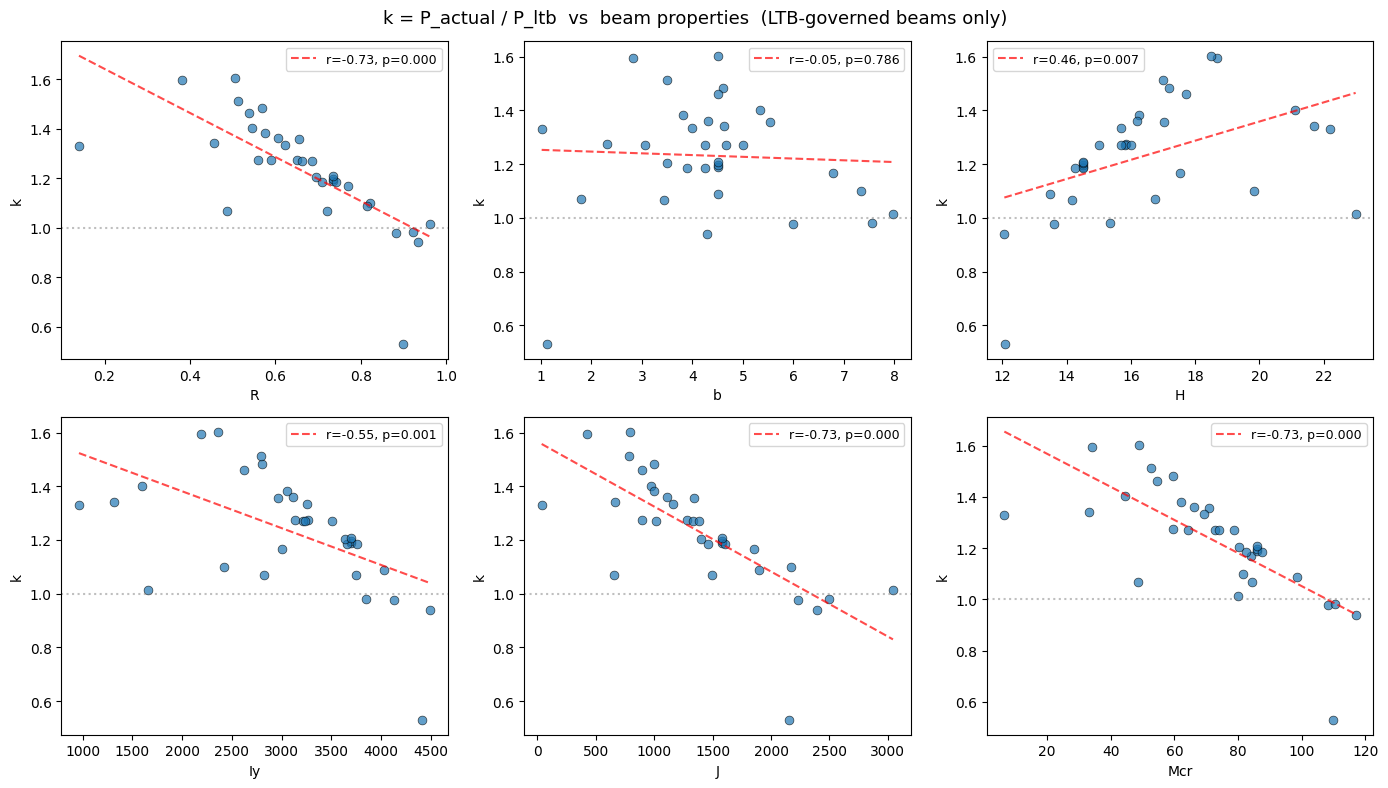

In [8]:
# === Scatter plots: k vs top candidates ===

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('k = P_actual / P_ltb  vs  beam properties  (LTB-governed beams only)', fontsize=13)

plot_vars = ['R', 'b', 'H', 'Iy', 'J', 'Mcr']

for ax, var in zip(axes.flat, plot_vars):
    x = ltb[var].values
    ax.scatter(x, k_vals, s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
    slope, intercept, r, p, se = stats.linregress(x, k_vals)
    xfit = np.linspace(x.min(), x.max(), 50)
    ax.plot(xfit, slope * xfit + intercept, 'r--', alpha=0.7,
            label=f'r={r:.2f}, p={p:.3f}')
    ax.set_xlabel(var)
    ax.set_ylabel('k')
    ax.legend(fontsize=9)
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

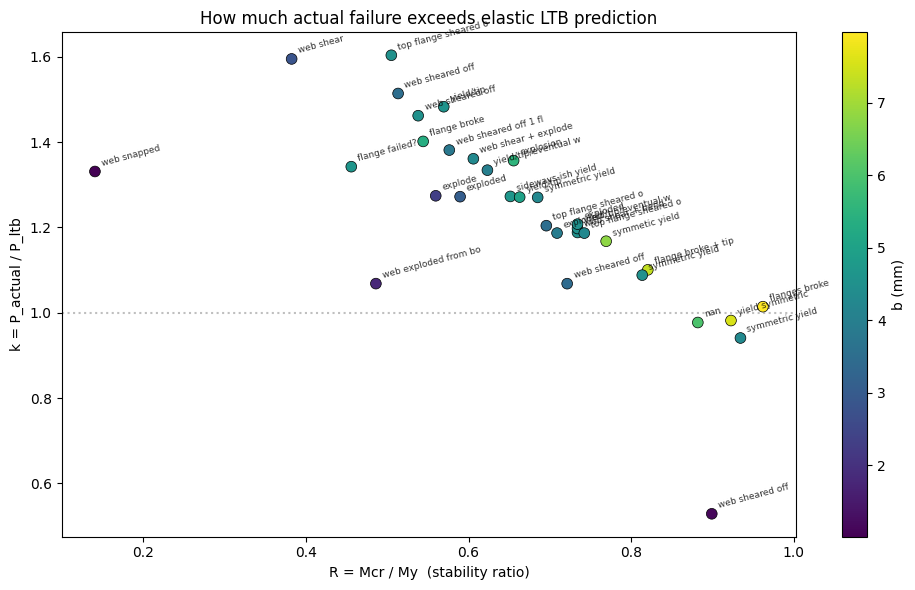

In [9]:
# === Scatter: k vs R with failure mode annotations ===

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(ltb['R'], ltb['k'], c=ltb['b'], cmap='viridis',
                s=60, edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='b (mm)')

for _, row in ltb.iterrows():
    ax.annotate(row['Failure'][:20], (row['R'], row['k']),
                fontsize=6.5, alpha=0.8, rotation=15,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('R = Mcr / My  (stability ratio)')
ax.set_ylabel('k = P_actual / P_ltb')
ax.set_title('How much actual failure exceeds elastic LTB prediction')
ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# === Multivariate: can we predict k from a combination? ===
# Try OLS with a few variables to see if R^2 improves.

from numpy.linalg import lstsq

# Standardize predictors for comparable coefficients
def standardize(x):
    return (x - x.mean()) / x.std() if x.std() > 0 else x * 0

# Model 1: k ~ R
# Model 2: k ~ R + b
# Model 3: k ~ R + b + H
# Model 4: k ~ R + log(Iy/Ix)

models = {
    'R only':          np.column_stack([standardize(ltb['R'].values), np.ones(len(ltb))]),
    'R + b':           np.column_stack([standardize(ltb['R'].values), standardize(ltb['b'].values), np.ones(len(ltb))]),
    'R + b + H':       np.column_stack([standardize(ltb['R'].values), standardize(ltb['b'].values), standardize(ltb['H'].values), np.ones(len(ltb))]),
    'R + log(Iy/Ix)':  np.column_stack([standardize(ltb['R'].values), standardize(np.log(ltb['Iy'].values / ltb['Ix'].values)), np.ones(len(ltb))]),
}

print(f'{"Model":>20}   R^2_adj   Residual std')
print('-' * 50)
for name, X in models.items():
    beta, residuals, rank, sv = lstsq(X, k_vals, rcond=None)
    k_pred = X @ beta
    ss_res = np.sum((k_vals - k_pred)**2)
    ss_tot = np.sum((k_vals - k_vals.mean())**2)
    n, p = X.shape
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else r2
    res_std = np.sqrt(ss_res / (n - p))
    print(f'{name:>20}   {r2_adj:.3f}     {res_std:.3f}')

               Model   R^2_adj   Residual std
--------------------------------------------------
              R only   0.496     0.149
               R + b   0.686     0.117
           R + b + H   0.772     0.100
      R + log(Iy/Ix)   0.493     0.149


In [11]:
# === Beam-by-beam table with failure modes ===

display_cols = ['Beam', 'b', 'H', 'Ix', 'Iy', 'J', 'R', 'Mcr',
                'P_ltb', 'P_bend', 'P_shear', 'P_triple', 'P_actual', 'k', 'Act/Bend',
                'Act/Shear', 'Failure', 'Notes']

print('Beam-by-beam results (LTB-governed only, sorted by k):')
print()
show = ltb[display_cols].sort_values('k')
print(show.to_string(index=False, float_format=lambda x: f'{x:.2f}' if abs(x) < 100 else f'{x:.0f}'))

Beam-by-beam results (LTB-governed only, sorted by k):

               Beam    b     H    Ix   Iy     J    R   Mcr  P_ltb  P_bend  P_shear  P_triple  P_actual    k  Act/Bend  Act/Shear                                  Failure                                           Notes
                 13 1.13 12.08 18649 4411  2151 0.90   110   2170    2413     1289      1289      1147 0.53      0.48       0.89                          web sheared off                                             nan
                  6 4.28 12.07 19118 4494  2397 0.93   117   2312    2474     4883      2312      2175 0.94      0.88       0.45                          symmetric yield                                             nan
                  8 5.99 13.62 18724 4127  2230 0.88   108   2137    2423     7710      2137      2088 0.98      0.86       0.27                                      nan                                             nan
                 11 7.56 15.34 18293 3849  2499 0.92   110   2184    236

In [12]:
# === Summary and interpretation ===

print('='*70)
print('FINDINGS')
print('='*70)
print()
print('1. k = P_actual / P_ltb is NOT constant across beams.')
print(f'   Range: {ltb["k"].min():.2f} to {ltb["k"].max():.2f},  CV = {ltb["k"].std()/ltb["k"].mean():.2f}')
print()

# Find strongest single-variable correlation
best_r2 = 0
best_name = ''
for name, x in candidates.items():
    _, _, r, p, _ = stats.linregress(x, k_vals)
    if r**2 > best_r2:
        best_r2 = r**2
        best_name = name
        best_r = r
        best_p = p

print(f'2. Strongest single-variable linear predictor of k: {best_name}')
print(f'   r = {best_r:+.3f},  r^2 = {best_r2:.3f},  p = {best_p:.4f}')
print()
print('3. Physical interpretation:')
print('   - Elastic Mcr is a bifurcation threshold, not ultimate capacity.')
print('   - Actual failure load exceeds Mcr because:')
print('     (a) Fixture restraint (rounded nose, support friction) raises true Mcr.')
print('     (b) Post-buckling reserve: beam can carry load past initial twist.')
print('     (c) Inelastic effects: short beams may plastify before elastic LTB.')
print('   - If k depends on R (or related properties), the fixture/post-buckling')
print('     effect is geometry-dependent, not a simple constant multiplier.')
print()
print('4. Implications for the student activity:')
print('   - R is still a useful physics feature for the GP.')
print('   - But the GP needs to learn a geometry-dependent correction, not')
print('     just a constant offset from the LTB model.')
print('   - This is exactly why data + physics outperforms physics alone.')

FINDINGS

1. k = P_actual / P_ltb is NOT constant across beams.
   Range: 0.53 to 1.60,  CV = 0.17

2. Strongest single-variable linear predictor of k: J
   r = -0.734,  r^2 = 0.538,  p = 0.0000

3. Physical interpretation:
   - Elastic Mcr is a bifurcation threshold, not ultimate capacity.
   - Actual failure load exceeds Mcr because:
     (a) Fixture restraint (rounded nose, support friction) raises true Mcr.
     (b) Post-buckling reserve: beam can carry load past initial twist.
     (c) Inelastic effects: short beams may plastify before elastic LTB.
   - If k depends on R (or related properties), the fixture/post-buckling
     effect is geometry-dependent, not a simple constant multiplier.

4. Implications for the student activity:
   - R is still a useful physics feature for the GP.
   - But the GP needs to learn a geometry-dependent correction, not
     just a constant offset from the LTB model.
   - This is exactly why data + physics outperforms physics alone.


=== Filter: b > 2 mm ===
Remaining LTB-governed beams: 30 of 33

--- Stats on k = P_actual / P_ltb ---
  Mean:   1.257
  Std:    0.176
  CV:     0.140

--- Correlations with k ---
 Predictor        r      r^2     p-value
         b   -0.456    0.208      0.0113
         H   +0.385    0.148      0.0356
        Ix   -0.505    0.255      0.0045
        Iy   -0.548    0.300      0.0017
         J   -0.887    0.786      0.0000
       Mcr   -0.882    0.778      0.0000
         R   -0.926    0.858      0.0000
     P_ltb   -0.882    0.778      0.0000
       b^3   -0.482    0.232      0.0071
     Iy/Ix   -0.499    0.249      0.0050
      J/Ix   -0.749    0.561      0.0000
       b*H   -0.221    0.049      0.2400


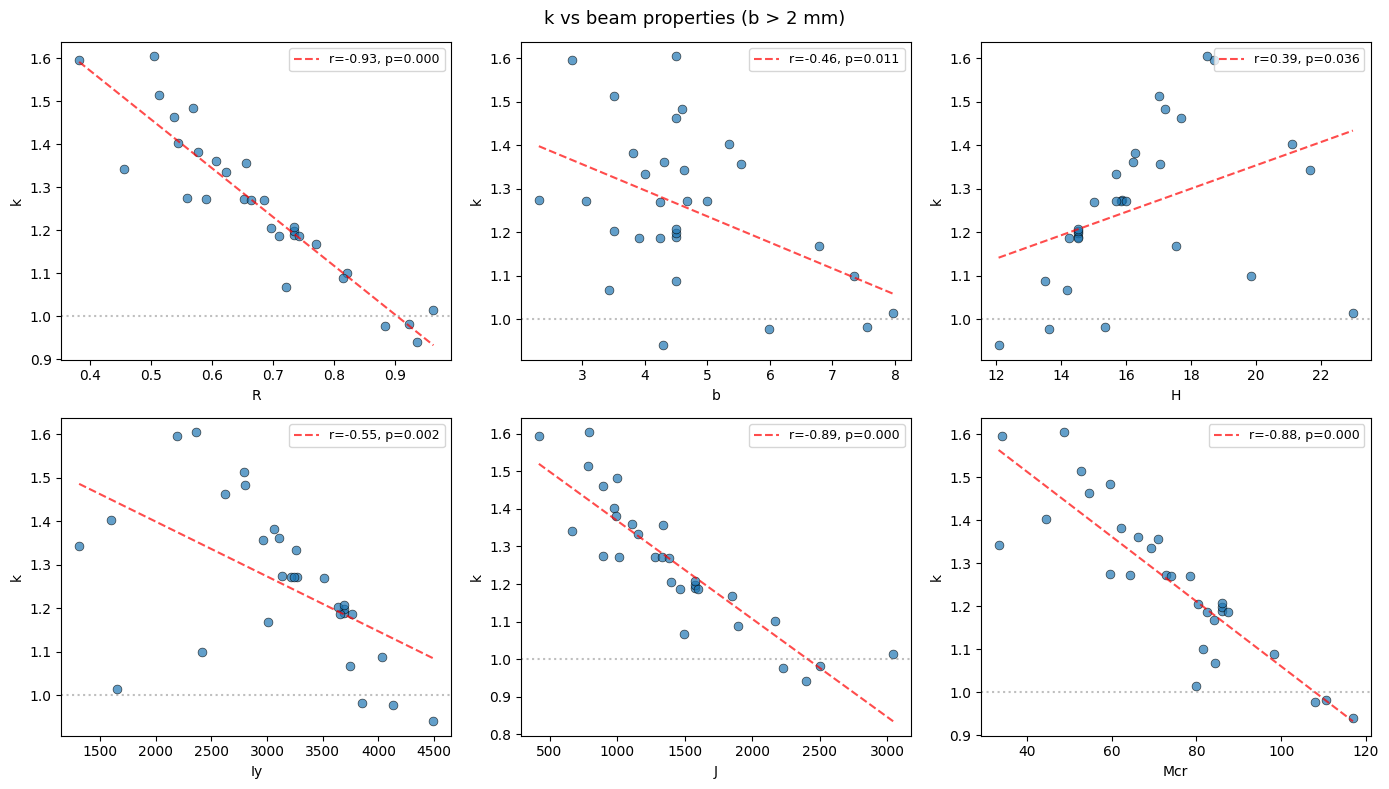

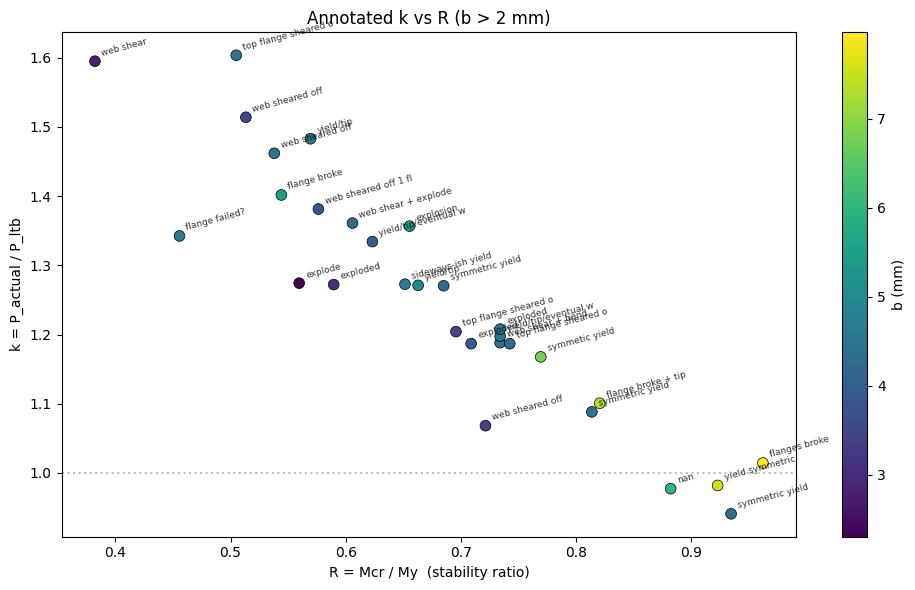


--- Multivariate OLS Models ---
               Model   R^2_adj   Residual std
--------------------------------------------------
              R only   0.847     0.068
               R + b   0.867     0.063
           R + b + H   0.868     0.063
      R + log(Iy/Ix)   0.844     0.068


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.linalg import lstsq

# === Analysis for beams with b > 2 mm ===
print("=== Filter: b > 2 mm ===")
ltb2 = ltb[ltb['b'] > 2.0].copy()
print(f'Remaining LTB-governed beams: {len(ltb2)} of {len(ltb)}')

print('\n--- Stats on k = P_actual / P_ltb ---')
print(f'  Mean:   {ltb2["k"].mean():.3f}')
print(f'  Std:    {ltb2["k"].std():.3f}')
print(f'  CV:     {ltb2["k"].std() / ltb2["k"].mean():.3f}')

# --- Correlations ---
candidates2 = {
    'b':   ltb2['b'].values,
    'H':   ltb2['H'].values,
    'Ix':  ltb2['Ix'].values,
    'Iy':  ltb2['Iy'].values,
    'J':   ltb2['J'].values,
    'Mcr': ltb2['Mcr'].values,
    'R':   ltb2['R'].values,
    'P_ltb': ltb2['P_ltb'].values,
    'b^3': ltb2['b'].values**3,
    'Iy/Ix': ltb2['Iy'].values / ltb2['Ix'].values,
    'J/Ix': ltb2['J'].values / ltb2['Ix'].values,
    'b*H': ltb2['b'].values * ltb2['H'].values,
}
k_vals2 = ltb2['k'].values

print('\n--- Correlations with k ---')
print(f'{"Predictor":>10}  {"r":>7}  {"r^2":>7}  {"p-value":>10}')
for name, x in candidates2.items():
    slope, intercept, r, p, se = stats.linregress(x, k_vals2)
    print(f'{name:>10}  {r:+7.3f}  {r**2:7.3f}  {p:10.4f}')

# --- Scatter Plots ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('k vs beam properties (b > 2 mm)', fontsize=13)
plot_vars = ['R', 'b', 'H', 'Iy', 'J', 'Mcr']
for ax, var in zip(axes.flat, plot_vars):
    x = ltb2[var].values
    ax.scatter(x, k_vals2, s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
    slope, intercept, r, p, se = stats.linregress(x, k_vals2)
    xfit = np.linspace(x.min(), x.max(), 50)
    ax.plot(xfit, slope * xfit + intercept, 'r--', alpha=0.7, label=f'r={r:.2f}, p={p:.3f}')
    ax.set_xlabel(var)
    ax.set_ylabel('k')
    ax.legend(fontsize=9)
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Scatter k vs R annotated ---
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(ltb2['R'], ltb2['k'], c=ltb2['b'], cmap='viridis', s=60, edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='b (mm)')

for _, row in ltb2.iterrows():
    ax.annotate(str(row['Failure'])[:20], (row['R'], row['k']),
                fontsize=6.5, alpha=0.8, rotation=15,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('R = Mcr / My  (stability ratio)')
ax.set_ylabel('k = P_actual / P_ltb')
ax.set_title('Annotated k vs R (b > 2 mm)')
ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

# --- OLS Models ---
def standardize2(x):
    return (x - x.mean()) / x.std() if x.std() > 0 else x * 0

models2 = {
    'R only':          np.column_stack([standardize2(ltb2['R'].values), np.ones(len(ltb2))]),
    'R + b':           np.column_stack([standardize2(ltb2['R'].values), standardize2(ltb2['b'].values), np.ones(len(ltb2))]),
    'R + b + H':       np.column_stack([standardize2(ltb2['R'].values), standardize2(ltb2['b'].values), standardize2(ltb2['H'].values), np.ones(len(ltb2))]),
    'R + log(Iy/Ix)':  np.column_stack([standardize2(ltb2['R'].values), standardize2(np.log(ltb2['Iy'].values / ltb2['Ix'].values)), np.ones(len(ltb2))]),
}

print('\n--- Multivariate OLS Models ---')
print(f'{"Model":>20}   R^2_adj   Residual std')
print('-' * 50)
for name, X in models2.items():
    beta, residuals, rank, sv = lstsq(X, k_vals2, rcond=None)
    k_pred = X @ beta
    ss_res = np.sum((k_vals2 - k_pred)**2)
    ss_tot = np.sum((k_vals2 - k_vals2.mean())**2)
    n, p = X.shape
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else r2
    res_std = np.sqrt(ss_res / (n - p))
    print(f'{name:>20}   {r2_adj:.3f}     {res_std:.3f}')

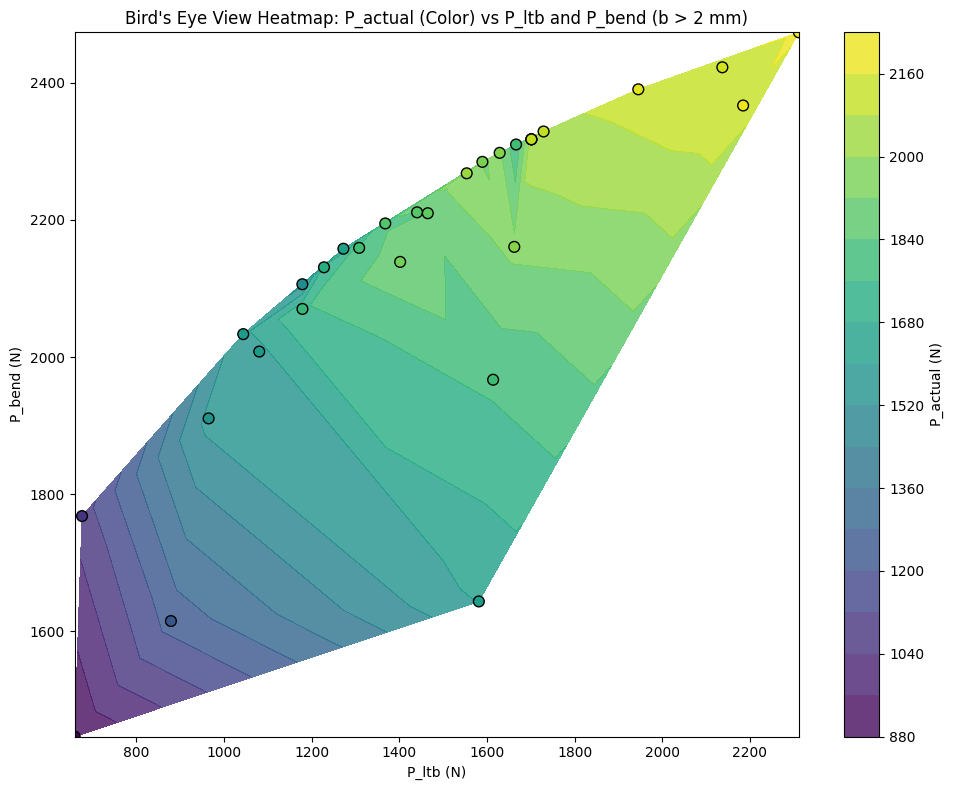

In [17]:
import matplotlib.pyplot as plt

# Use ltb2 which contains only beams with b > 2 mm
x = ltb2['P_ltb']
y = ltb2['P_bend']
z = ltb2['P_actual']

fig, ax = plt.subplots(figsize=(10, 8))

# Create a continuous heatmap background using triangulation
cntr = ax.tricontourf(x, y, z, levels=20, cmap='viridis', alpha=0.8)

# Overlay the actual data points
ax.scatter(x, y, c=z, cmap='viridis', s=60, edgecolors='k')

# Adding labels and title
ax.set_xlabel('P_ltb (N)')
ax.set_ylabel('P_bend (N)')
ax.set_title("Bird's Eye View Heatmap: P_actual (Color) vs P_ltb and P_bend (b > 2 mm)")

# Add a colorbar for P_actual
cbar = plt.colorbar(cntr, ax=ax)
cbar.set_label('P_actual (N)')

plt.tight_layout()
plt.show()

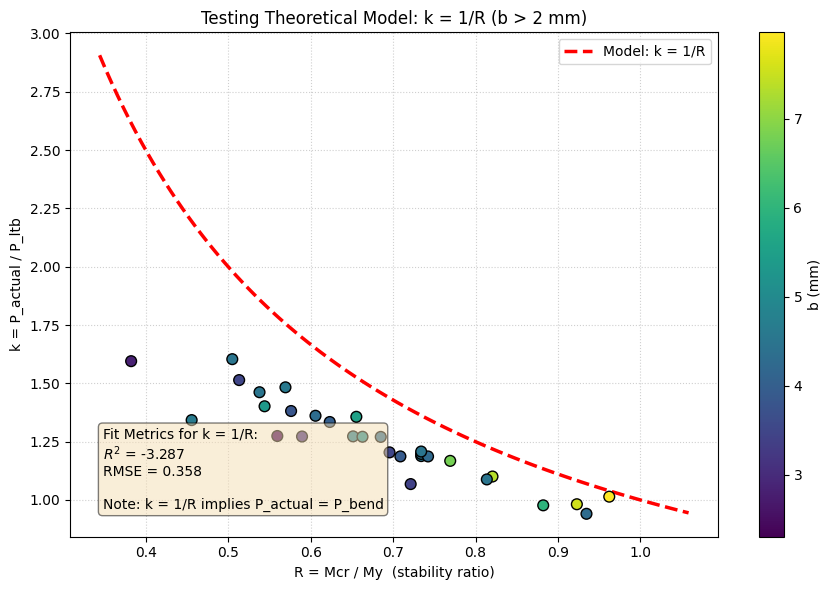

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Use the filtered data (b > 2 mm)
R_vals = ltb2['R'].values
k_vals = ltb2['k'].values

# Theoretical model: k = 1 / R
# Note physically: k = P_act/P_ltb and R = P_ltb/P_bend.
# If k = 1/R, then P_act/P_ltb = P_bend/P_ltb -> P_act = P_bend.
k_pred = 1.0 / R_vals

# Calculate fit metrics
ss_res = np.sum((k_vals - k_pred)**2)
ss_tot = np.sum((k_vals - np.mean(k_vals))**2)
r2 = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean((k_vals - k_pred)**2))

# Plotting
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter of actual data
sc = ax.scatter(R_vals, k_vals, c=ltb2['b'], cmap='viridis', s=60, edgecolors='k', zorder=3)
plt.colorbar(sc, ax=ax, label='b (mm)')

# Smooth curve for k = 1/R
R_line = np.linspace(min(R_vals)*0.9, max(R_vals)*1.1, 100)
k_line = 1.0 / R_line
ax.plot(R_line, k_line, 'r--', linewidth=2.5, label='Model: k = 1/R', zorder=2)

ax.set_xlabel('R = Mcr / My  (stability ratio)')
ax.set_ylabel('k = P_actual / P_ltb')
ax.set_title('Testing Theoretical Model: k = 1/R (b > 2 mm)')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

# Annotate with fit metrics
textstr = f"Fit Metrics for k = 1/R:\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\n\nNote: k = 1/R implies P_actual = P_bend"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.05, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.show()
